In [1]:
import pandas as pd

In [2]:
movies = pd.read_csv("http://bit.ly/imdbratings")

In [3]:
movies.head()

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."


In [4]:
movies.dtypes

,0
star_rating,float64
title,object
content_rating,object
genre,object
duration,int64
actors_list,object


In [5]:
movies.genre.describe()

,genre
count,979
unique,16
top,Drama
freq,278


In [7]:
movies.genre.value_counts()

,count
genre,
Drama,278
Comedy,156
Action,136
Crime,124
Biography,77
Adventure,75
Animation,62
Horror,29
Mystery,16


In [9]:
movies.genre.value_counts(normalize=True)*100

,proportion
genre,
Drama,28.396323
Comedy,15.934627
Action,13.891726
Crime,12.665986
Biography,7.865169
Adventure,7.660878
Animation,6.332993
Horror,2.962206
Mystery,1.634321


In [11]:
movies.genre.nunique()

16

In [10]:
movies.genre.unique()

array(['Crime', 'Action', 'Drama', 'Western', 'Adventure', 'Biography',
       'Comedy', 'Animation', 'Mystery', 'Horror', 'Film-Noir', 'Sci-Fi',
       'History', 'Thriller', 'Family', 'Fantasy'], dtype=object)

In [13]:
movies.content_rating

,content_rating
0,R
1,R
2,R
3,PG-13
4,R
...,...
974,PG
975,PG
976,PG-13
977,PG


In [12]:
movies.genre

,genre
0,Crime
1,Crime
2,Crime
3,Action
4,Crime
...,...
974,Comedy
975,Adventure
976,Action
977,Horror


In [14]:
pd.crosstab(movies.genre,movies.content_rating)

content_rating,APPROVED,G,GP,NC-17,NOT RATED,PASSED,PG,PG-13,R,TV-MA,UNRATED,X
genre,,,,,,,,,,,,
Action,3,1,1,0,4,1,11,44,67,0,3,0
Adventure,3,2,0,0,5,1,21,23,17,0,2,0
Animation,3,20,0,0,3,0,25,5,5,0,1,0
Biography,1,2,1,0,1,0,6,29,36,0,0,0
Comedy,9,2,1,1,16,3,23,23,73,0,4,1
Crime,6,0,0,1,7,1,6,4,87,0,11,1
Drama,12,3,0,4,24,1,25,55,143,1,9,1
Family,0,1,0,0,0,0,1,0,0,0,0,0
Fantasy,0,0,0,0,0,0,0,0,1,0,0,0


In [15]:
movies.duration.describe()

,duration
count,979.000000
mean,120.979571
std,26.218010
min,64.000000
25%,102.000000
50%,117.000000
75%,134.000000
max,242.000000


<Axes: ylabel='Frequency'>

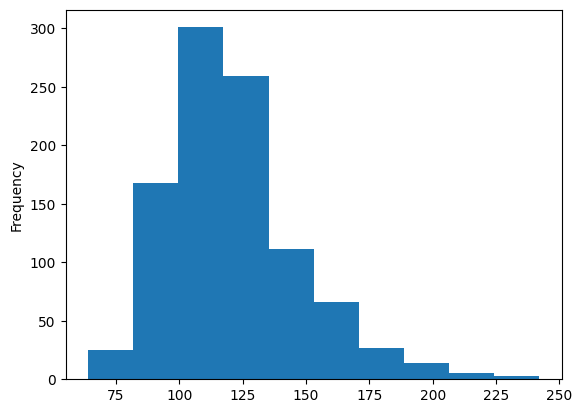

In [16]:
movies.duration.plot(kind='hist')

<Axes: xlabel='genre'>

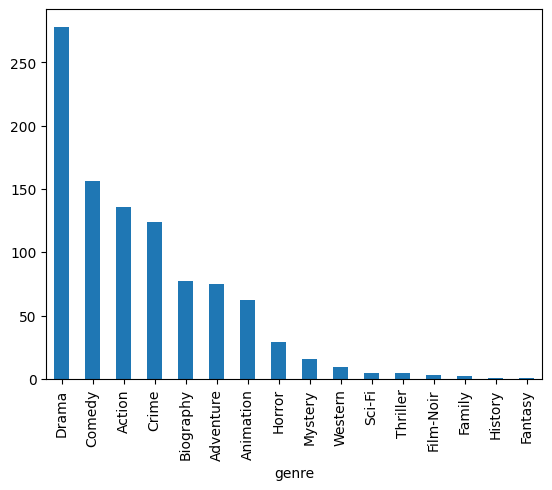

In [17]:
movies.genre.value_counts().plot(kind='bar')

In [ ]:
### Handle Missing Values in Pandas

In [18]:
ufo = pd.read_csv("http://bit.ly/uforeports")
ufo.tail()

,City,Colors Reported,Shape Reported,State,Time
18236,Grant Park,NaN,TRIANGLE,IL,12/31/2000 23:00
18237,Spirit Lake,NaN,DISK,IA,12/31/2000 23:00
18238,Eagle River,NaN,NaN,WI,12/31/2000 23:45
18239,Eagle River,RED,LIGHT,WI,12/31/2000 23:45
18240,Ybor,NaN,OVAL,FL,12/31/2000 23:59


In [ ]:
'''
* NaN is not a string, special value : numpy.nan
* NaN -- "Not a number" and it indicates missing value
'''

In [19]:
ufo.isnull().tail()

,City,Colors Reported,Shape Reported,State,Time
18236,False,True,False,False,False
18237,False,True,False,False,False
18238,False,True,True,False,False
18239,False,False,False,False,False
18240,False,True,False,False,False


In [20]:
ufo.notnull().tail()

,City,Colors Reported,Shape Reported,State,Time
18236,True,False,True,True,True
18237,True,False,True,True,True
18238,True,False,False,True,True
18239,True,True,True,True,True
18240,True,False,True,True,True


In [21]:
ufo.isnull().sum()

,0
City,26
Colors Reported,15359
Shape Reported,2644
State,0
Time,0


In [22]:
ufo[ufo.City.isnull()].head()

,City,Colors Reported,Shape Reported,State,Time
21,NaN,NaN,NaN,LA,8/15/1943 0:00
22,NaN,NaN,LIGHT,LA,8/15/1943 0:00
204,NaN,NaN,DISK,CA,7/15/1952 12:30
241,NaN,BLUE,DISK,MT,7/4/1953 14:00
613,NaN,NaN,DISK,NV,7/1/1960 12:00


In [23]:
ufo.shape

(18241, 5)

In [24]:
ufo.dropna(how='any').shape  ## if any values are missing in a row, then drop that row

(2486, 5)

In [25]:
ufo.dropna(how='all').shape  ## if all values are missing in a row, then drop that row

(18241, 5)

In [26]:
ufo.dropna(subset=['City','Shape Reported'],how='any').shape
##if any values are missing in a row (only City and Shape Reported), then drop that row

(15575, 5)

In [27]:
ufo.dropna(subset=['City','Shape Reported'],how='all').shape
##if any values are missing in a row (only City and Shape Reported), then drop that row

(18237, 5)

In [29]:
ufo['Shape Reported'].value_counts(dropna=False)

,count
Shape Reported,
LIGHT,2803
NaN,2644
DISK,2122
TRIANGLE,1889
OTHER,1402
CIRCLE,1365
SPHERE,1054
FIREBALL,1039
OVAL,845


In [30]:
ufo['Shape Reported'].fillna(value='VARIOUS', inplace=True)

/tmp/ipython-input-1909117351.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ufo['Shape Reported'].fillna(value='VARIOUS', inplace=True)


In [31]:
ufo['Shape Reported'].value_counts(dropna=False)

,count
Shape Reported,
VARIOUS,2977
LIGHT,2803
DISK,2122
TRIANGLE,1889
OTHER,1402
CIRCLE,1365
SPHERE,1054
FIREBALL,1039
OVAL,845


In [51]:
ufo = pd.read_csv("http://bit.ly/uforeports")
ufo.head()

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00
3,Abilene,NaN,DISK,KS,6/1/1931 13:00
4,New York Worlds Fair,NaN,LIGHT,NY,4/18/1933 19:00


In [52]:
ufo = ufo.set_index('Time')
ufo.tail()

,City,Colors Reported,Shape Reported,State
Time,,,,
12/31/2000 23:00,Grant Park,NaN,TRIANGLE,IL
12/31/2000 23:00,Spirit Lake,NaN,DISK,IA
12/31/2000 23:45,Eagle River,NaN,NaN,WI
12/31/2000 23:45,Eagle River,RED,LIGHT,WI
12/31/2000 23:59,Ybor,NaN,OVAL,FL


In [53]:
ufo.fillna(method='bfill').tail()

/tmp/ipython-input-463668170.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ufo.fillna(method='bfill').tail()


,City,Colors Reported,Shape Reported,State
Time,,,,
12/31/2000 23:00,Grant Park,RED,TRIANGLE,IL
12/31/2000 23:00,Spirit Lake,RED,DISK,IA
12/31/2000 23:45,Eagle River,RED,LIGHT,WI
12/31/2000 23:45,Eagle River,RED,LIGHT,WI
12/31/2000 23:59,Ybor,NaN,OVAL,FL


In [54]:
ufo.fillna(method='ffill').tail()

/tmp/ipython-input-2710079311.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ufo.fillna(method='ffill').tail()


,City,Colors Reported,Shape Reported,State
Time,,,,
12/31/2000 23:00,Grant Park,RED,TRIANGLE,IL
12/31/2000 23:00,Spirit Lake,RED,DISK,IA
12/31/2000 23:45,Eagle River,RED,DISK,WI
12/31/2000 23:45,Eagle River,RED,LIGHT,WI
12/31/2000 23:59,Ybor,RED,OVAL,FL


In [ ]:
## Pandas Indexing

In [32]:
drinks = pd.read_csv("http://bit.ly/drinksbycountry")
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,Asia
1,Albania,89,132,54,4.9,Europe
2,Algeria,25,0,14,0.7,Africa
3,Andorra,245,138,312,12.4,Europe
4,Angola,217,57,45,5.9,Africa


In [33]:
drinks.index

RangeIndex(start=0, stop=193, step=1)

In [34]:
drinks.continent.head()

,continent
0,Asia
1,Europe
2,Africa
3,Europe
4,Africa


In [35]:
drinks.set_index('country',inplace=True)

In [36]:
drinks.continent.head()

,continent
country,
Afghanistan,Asia
Albania,Europe
Algeria,Africa
Andorra,Europe
Angola,Africa


In [37]:
people = pd.Series([3000000,85000], index=['Albania','Andorra'],name='population')
people

,population
Albania,3000000
Andorra,85000


In [38]:
(drinks.beer_servings * people).head()

,0
Afghanistan,NaN
Albania,267000000.0
Algeria,NaN
Andorra,20825000.0
Angola,NaN


In [39]:
pd.concat([drinks,people],axis=1).head()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent,population
Afghanistan,0,0,0,0.0,Asia,NaN
Albania,89,132,54,4.9,Europe,3000000.0
Algeria,25,0,14,0.7,Africa,NaN
Andorra,245,138,312,12.4,Europe,85000.0
Angola,217,57,45,5.9,Africa,NaN


In [ ]:
### Select Multiple rows and columns

In [40]:
ufo = pd.read_csv("http://bit.ly/uforeports")

In [41]:
## row 0, all columns

ufo.loc[0,:]

,0
City,Ithaca
Colors Reported,NaN
Shape Reported,TRIANGLE
State,NY
Time,6/1/1930 22:00


In [42]:
ufo.loc[[0,1,2],:]
## rows 0 and 1 and 2, all columns

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00


In [43]:
ufo.loc[0:2,:]

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00


In [45]:
ufo.loc[0:2]

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00


In [46]:
ufo.loc[0:2,'City']

,City
0,Ithaca
1,Willingboro
2,Holyoke


In [47]:
ufo.loc[0:2,['City','State']]

,City,State
0,Ithaca,NY
1,Willingboro,NJ
2,Holyoke,CO


In [48]:
## rows in positions 0 and 1, columns in positions 0 and 3
ufo.iloc[[0,1],[0,3]]

,City,State
0,Ithaca,NY
1,Willingboro,NJ


In [49]:
ufo.iloc[0:2,0:4]

,City,Colors Reported,Shape Reported,State
0,Ithaca,NaN,TRIANGLE,NY
1,Willingboro,NaN,OTHER,NJ


In [50]:
ufo.iloc[0:2,:]

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
